# Name
Please write your name down here:

Peter Brederlow

**Association tests between variants and continuous phenotypes**
Yesterday we had learned how to test for association between categorical variables: our variables were genotype and color.

The phenotype data provided in the multi-omics publication is not categorical. We thus have to adapt our approach to deal with continuous data. In the lecture you saw that linear (Pearson's), logistic, or rank-based (Mann-Whitney U) tests can be used when one of the variables is categorical, and the other is categorical.

If the categorical variable is binary, and the continuous variable is normally distributed, a t-test can be used: Student's t-test if the variances of the two groups is identical, and the Welch's t-test otherwise.

In this notebook we will only use Pearson's correlation and the Mann-Whitney U-test.

(And a little note on nomenclature: the conventional name of Pearson's correlation is "point-biserial correlation" if one of the variables is binary. They are exactly the same thing, but if you ever come across the latter, remember that it refers to a special case of Pearson's correlation. Despite our genotypes being *almost* binary, we will keep using the term Pearson's correlation.)

In [119]:
import math
import pandas as pd
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.sandbox.stats.multicomp import multipletests

# Preparing the data
## Loading the genotype data
Loading the genotype data is routine by now: separating data from metadata, and converting the B-D-H-U labels into numbers. This time, we will avoid wasting any of our precious data, and instead of dropping strains with too many unknowns, we will work our way around them. We will treat the unknown `U` genotypes as `NaN` values.

In [120]:
genotype = pd.read_csv("https://raw.githubusercontent.com/Practical-Integrative-Bioinformatics/Introduction/refs/heads/main/data/genotype.txt", sep="\t", comment="@")
genotype.set_index("Locus", inplace=True)
geno_meta = genotype.iloc[:, :3]
geno_bdh = genotype.iloc[:, 3:]
geno = geno_bdh.replace(['B', 'H', 'D', 'U'], [0, 1, 2, np.nan])
geno.columns.name = 'strain'

geno['C57BL/6J'] = 0
geno['DBA/2J'] = 2
geno

strain,BXD1,BXD2,BXD5,BXD6,BXD8,BXD9,BXD11,BXD12,BXD13,BXD14,...,BXD93,BXD94,BXD95,BXD98,BXD99,BXD100,BXD101,BXD102,C57BL/6J,DBA/2J
Locus,,,,,,,,,,,,,,,,,,,,,
rs6269442,0,0,2,2,2,0,0,2,0,0,...,0,2,2,0,0,0,0,0,0,2
rs6365999,0,0,2,2,2,0,0,2,0,0,...,0,2,2,0,0,0,0,NaN,0,2
rs6376963,0,0,2,2,2,0,0,2,0,0,...,0,2,2,0,0,0,0,NaN,0,2
rs3677817,0,0,2,2,2,0,0,2,0,0,...,0,2,2,0,0,0,0,NaN,0,2
rs8236463,0,0,2,2,2,0,2,2,0,0,...,0,2,2,0,0,0,0,NaN,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CEL-X_154259201,0,0,0,2,0,0,0,0,2,0,...,2,2,1,2,2,0,NaN,NaN,0,2
rs3657281,0,0,0,2,0,0,0,0,2,0,...,2,2,1,2,2,0,NaN,NaN,0,2
rs13484106,0,0,0,2,0,0,0,0,2,0,...,2,2,1,2,2,0,NaN,NaN,0,2


## Loading the phenotype tables

As for the phenotype spreadsheets, we will always use the `split_cd_hfd(...)`-transformed version from now on. We have provided its code so you don't have to dig it up from Tuesday. Let's convert all sheets with `split_cd_hfd` and forget about it. From now on, the `phenotypes` dictionary will always contain the nice CD/HFD-indexed DataFrames.

In [121]:
phenotypes_ugly = pd.read_excel('https://raw.githubusercontent.com/Practical-Integrative-Bioinformatics/Introduction/refs/heads/main/data/phenotype.xlsx', sheet_name=None, na_values='x', index_col=0)

# The VO2Max table doesn't follow their own column naming conventions, so we fix that first
def rename_vo2_cols(colname):
    return colname.replace('CD', 'CD_').replace('HFD', 'HFD_').replace('__', '_')

phenotypes_ugly['VO2Max'].rename(columns=rename_vo2_cols, inplace=True)

def split_cd_hfd(input_df):
    input_df.index.name = 'strain'  # change that weird @format=column Excel index label to something meaningful
    input_cd = input_df.filter(regex=r'_CD|CD_') # loc[:, (input_df.columns.str.contains('CD_')) | (input_df.columns.str.contains('_CD'))]
    input_hfd = input_df.filter(regex=r'_HFD|HFD_') #loc[:, (input_df.columns.str.contains('HFD_')) | (input_df.columns.str.contains('_HFD'))]

    input_cd.columns = input_cd.columns.str.replace(r'_CD|CD_', '', regex=True)
    input_hfd.columns = input_hfd.columns.str.replace(r'_HFD|HFD_', '', regex=True)
    
    input_cd.insert(0, 'diet', 'CD')
    input_hfd.insert(0, 'diet', 'HFD')
    
    kept_columns = input_cd.columns.intersection(input_hfd.columns)
    # kept_columns = input_cd.columns & input_hfd.columns  # this also works
    
    df_both = pd.concat([input_cd, input_hfd], sort=False)[kept_columns]
    df_both.columns.name = 'experiment'  # added only later
    
    return df_both.set_index('diet', append=True).sort_index()

# for every sheet (other than the last empty one) we do a split_cd_hfd and then drop
# columns that are admittedly problematic for statistical testing.
# Those columns have "KNOWN_BATCH_EFFECT_BY_COHORT_ORDER" in their names, which we can
# filter out with a tricky regex (sadly .filter() doesn't have an invert=True keyword)

phenotypes = {sheet_name: split_cd_hfd(sheet).filter(regex=r'^(?!.*BATCH).*$')
              for sheet_name, sheet in phenotypes_ugly.items() if sheet_name != 'NEW'}

phenotypes['Biochemistry']  # nice CD/HFD DataFrame without the bad columns

/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/opt/homebrew/anaconda3/envs/PrInegrBioInf/lib/python3.14/site-pa

experiment     Glucose_[mmol/L]  Cholesterol_[mmol/L]  HDL_Norm[Z]  \
strain   diet                                                        
BXD1     CD             8.90000              2.920000          NaN   
         HFD           13.92000              3.200000          NaN   
BXD100   CD            16.63333              4.600000     0.131568   
         HFD           17.92000              6.520000     0.881388   
BXD101   CD            17.40000              3.480000    -0.443989   
...                         ...                   ...          ...   
BXD99    HFD           19.66000              5.120000     0.989822   
C57BL/6J CD            15.10000              3.666667    -0.211906   
         HFD           21.46000              5.600000     0.291778   
DBA/2J   CD            15.35000              3.550000    -0.047737   
         HFD           16.38000              4.440000     0.501355   

experiment     LDL_[mmol/L]  Triglycerides_[mmol/L]  FFA_Norm[Z]  \
strain   diet                                                      
BXD1     CD        0.156000                0.578000          NaN   
         HFD       0.194000                0.846000          NaN   
BXD100   CD        0.123333                1.466667    -0.498691   
         HFD       0.334000                1.324000    -0.573159   
BXD101   CD        0.135000                1.883000     1.158929   
...                     ...                     ...          ...   
BXD99    HFD       0.194000                1.502000    -0.773079   
C57BL/6J CD        0.066667                1.280000     0.654811   
         HFD       0.372000                0.910000     0.872932   
DBA/2J   CD        0.030000                1.666667     2.824702   
         HFD       0.140000                1.855000     1.244267   

experiment     LacticAcid_[mmol/L]  BloodProtein_[g/L]  ASAT_[U/L]  \
strain   diet                                                        
BXD1     CD                  2.420              54.220    87.00000   
         HFD                 3.040              52.340    45.00000   
BXD100   CD                  2.700              53.800    33.66667   
         HFD                 3.700              50.220    52.40000   
BXD101   CD                  4.825              48.930    81.00000   
...                            ...                 ...         ...   
BXD99    HFD                 3.660              53.740    79.00000   
C57BL/6J CD                  7.950              59.700    48.33333   
         HFD                 3.660              64.320    54.00000   
DBA/2J   CD                  6.425              56.625    43.00000   
         HFD                 5.640              59.760    50.40000   

experiment     ASAT_Norm[Z]  LDH_Norm[Z]  ALPL_[U/L]  Amylase_[U/L]  \
strain   diet                                                         
BXD1     CD             NaN          NaN   127.60000       1052.500   
         HFD            NaN          NaN    70.20000       1070.600   
BXD100   CD       -0.624291    -0.598639    94.33334       1051.000   
         HFD      -0.393496    -0.131280    68.00000       1099.600   
BXD101   CD       -0.383754    -0.321445    77.30000        878.300   
...                     ...          ...         ...            ...   
BXD99    HFD      -0.407235    -0.113847    93.20000        925.400   
C57BL/6J CD       -0.447704    -0.305917    63.33333       1199.667   
         HFD      -0.193912    -0.400335    61.60000       1169.200   
DBA/2J   CD       -0.509304    -0.917519    95.50000       1021.500   
         HFD      -0.418136    -0.775020    62.40000       1145.800   

experiment     CreatineKinase_[U/L]  Creatinine_Norm[Z]  Iron_[umol/L]  
strain   diet                                                           
BXD1     CD               530.00000                 NaN       22.67500  
         HFD               98.00000                 NaN       25.52500  
BXD100   CD                57.66667            0.674354       26.50000  
    

## Reindexing the genotype DataFrame to match the format of the phenotype DataFrames

Since we will spend the day comparing genotypes with phenotypes, it is worth preprocessing our data a bit to make comparisons easier. The `geno` DataFrame has strains as columns, whereas the `phenotypes[...]` DataFrames have strains as rows. Furthermore, due to most phenotype measurements having been performed twice (once under the CD and once under the HFD diet) we have two rows per each strain in the phenotype DataFrames.

Reshaping DataFrames is a common task, and `pandas` can do the work for us with the `.reindex()` method.

Let's reindex the `geno` DataFrame to match the index structure of the phenotype DataFrames. We will have to do two things: first transpose `geno` and then `.reindex(...)` it with the index object of any phenotype DataFrame from the `phenotypes` dictionary. Since the phenotype DataFrames have a MultiIndex, we will also have to tell the `reindex` method which level we want to match it on. Store the re-indexed genotype DataFrame in `geno2`.

In [122]:
# YOUR CODE HERE
geno = geno.T
phenotype_index = list(phenotypes.values())[0].index
geno2 = geno.reindex(phenotype_index, level=0)
geno2

Locus         rs6269442 rs6365999 rs6376963 rs3677817 rs8236463 rs6333200  \
strain   diet                                                               
BXD1     CD           0         0         0         0         0         0   
         HFD          0         0         0         0         0         0   
BXD100   CD           0         0         0         0         0         0   
         HFD          0         0         0         0         0         0   
BXD101   CD           0         0         0         0         0         0   
...                 ...       ...       ...       ...       ...       ...   
BXD99    HFD          0         0         0         0         0         0   
C57BL/6J CD           0         0         0         0         0         0   
         HFD          0         0         0         0         0         0   
DBA/2J   CD           2         2         2         2         2         2   
         HFD          2         2         2         2         2         2   

Locus         rs6298633 rs6241531 rs6360236 rs3722996  ... CEL-X_143438541  \
strain   diet                                          ...                   
BXD1     CD           0         0         0         0  ...               0   
         HFD          0         0         0         0  ...               0   
BXD100   CD           0         0         0         0  ...               0   
         HFD          0         0         0         0  ...               0   
BXD101   CD           0         0         0         0  ...             NaN   
...                 ...       ...       ...       ...  ...             ...   
BXD99    HFD          0         0         0         0  ...               0   
C57BL/6J CD           0         0         0         0  ...               0   
         HFD          0         0         0         0  ...               0   
DBA/2J   CD           2         2         2         2  ...               2   
         HFD          2         2         2         2  ...               2   

Locus         CEL-X_143595976 rs13484097 gnfX.141.820 CEL-X_154048891  \
strain   diet                                                           
BXD1     CD                 0          0            0               0   
         HFD                0          0            0               0   
BXD100   CD                 0          0            0               0   
         HFD                0          0            0               0   
BXD101   CD               NaN        NaN          NaN             NaN   
...                       ...        ...          ...             ...   
BXD99    HFD                2          2            2               2   
C57BL/6J CD                 0          0            0               0   
         HFD                0          0            0               0   
DBA/2J   CD                 2          2            2               2   
         HFD                2          2            2               2   

Locus         CEL-X_154259201 rs3657281 rs13484106 gnfX.146.867 DXMit223  
strain   diet                                                             
BXD1     CD                 0         0          0            0        0  
         HFD                0         0          0            0        0  
BXD100   CD                 0         0          0            0        0  
         HFD                0         0          0            0        0  
BXD101   CD               NaN       NaN        NaN          NaN      NaN  
...                       ...       ...        ...          ...      ...  
BXD99    HFD                2         2          2            2        2  
C57BL/6J CD                 0         0          0            0        0  
         HFD                0         0          0            0        0  
DBA/2J   CD                 2         2          2            2        2  
         HFD                2         2          2            2        2  

[114 rows x 3811 columns]

In [123]:
assert 'geno2' in locals()

<div class="alert alert-block alert-info"><b>Note: </b> Since the genotype and phenotype DataFrames contained different sets of strains, <code>pandas</code> had to discard 38 strains from <code>geno</code> and introduce 2 strains with all missing values. This was the price of getting the genotype and phenotype DataFrames lined up.</div>

Of course we couldn't have used those 38 discarded strains for anything, since we don't have any phenotype information for them. The 2 extra strains with fully unknown genotypes are equally useless, but they don't bother us: while we could have removed them from all 11 phenotype sheets instead of inserting them into the `geno2` DataFrame, it's not worth the effort, since we already have to deal with a lot of missing data anyway. Remember, we have other `NaN`s in both the genotype and phenotype tables.

# Implement Pearson's r-based test for correlation between a genotype and a phenotype

Choose a phenotype whose genetic associations you want to study, for example `Glucose_[mmol/L]` from the `Biochemistry` sheet. Store this Series under the name `one_pheno`.

Likewise, choose a locus from `geno2`, e.g. `rs3677240`. Store its genotypes in the Series `one_geno`.

Perform a Pearson's correlation test between the two using `stats.pearsonr`. The function expects two arrays or Series with matching elements. Thankfully our previous reindexing has already taken care of that.

Unfortunately, as you'll immediately see, the `stats.pearsonr` function can't handle `NaN` values. So make sure to remove elements from *both* Series where *either of them* is an NaN.

You can achieve this with boolean slicing: a Series' `.isna()` method gives you a boolean vector with `True` elements at the missing values' positions. You can combine and invert boolean vectors with logical operators, and use the resulting mask to slice both the genotype and phenotype Series at the necessary positions.

If everything works, wrap these two steps (i.e. NaN masking and Pearson correlation) into a function named `pearson_between(one_geno, one_pheno)` which takes the two Series as inputs, and returns the Pearson correlation test's p-value.

In [124]:
# YOUR CODE HERE
biochem = phenotypes['Biochemistry']
one_pheno = biochem.iloc[:, 0]
one_pheno.head(20)

one_geno = geno2['rs3677240']
one_geno.head(20)

def pearson_between(geno_series, pheno_series):
    geno_series = pd.to_numeric(geno_series, errors='coerce')
    pheno_series = pd.to_numeric(pheno_series, errors='coerce')
    valid_indices = geno_series.notna() & pheno_series.notna()
    geno_valid = geno_series[valid_indices]
    pheno_valid = pheno_series[valid_indices]
    correlation, p_value = stats.pearsonr(geno_valid, pheno_valid)
    return p_value
pearson_p = pd.to_numeric(pearson_between(one_geno, one_pheno))
pearson_p

np.float64(0.009306461192027344)

In [125]:
assert 'one_pheno' in locals()
assert 'one_geno' in locals()
assert math.isclose(pearson_between(geno2['rs3677240'], phenotypes['Biochemistry']['Glucose_[mmol/L]']), 0.0093, abs_tol=1e-4)

# Visualize the phenotype value distributions of the B and D genotype

Two transparent histograms on the same plot should do the job. **Based on the p-value that you had previously calculated, does the histogram match your expectations?**

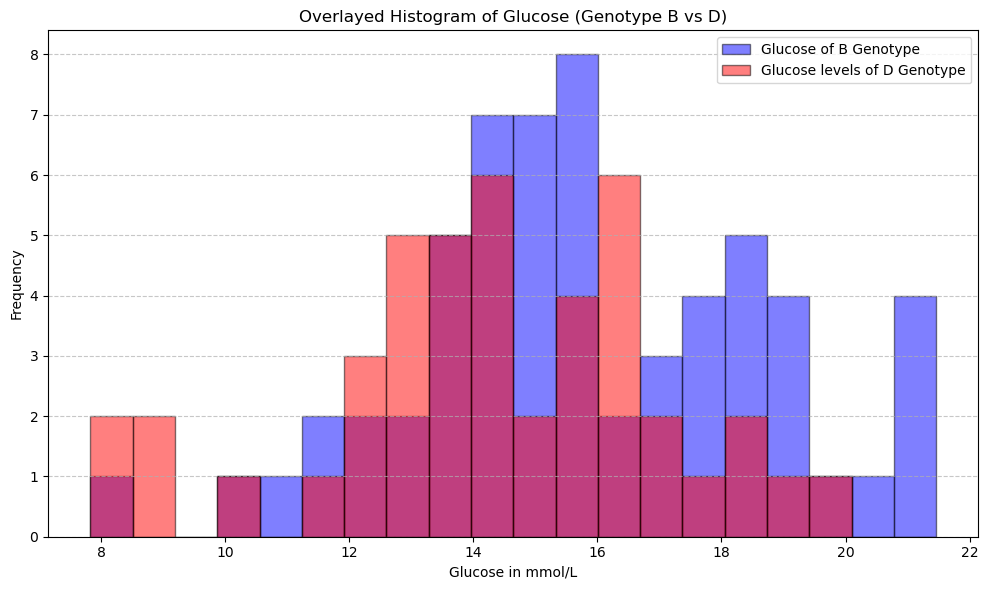

In [126]:
# YOUR CODE HERE
glucose_B = one_pheno[one_geno == 0]
glucose_D = one_pheno[one_geno == 2]

#plot histogram
min_value = min(glucose_B.min(), glucose_D.min())
max_value = max(glucose_B.max(), glucose_D.max())
bins = np.linspace(min_value, max_value, 21) 
plt.figure(figsize=(10, 6))
plt.hist(glucose_B, bins=bins, color='blue', alpha=0.5, edgecolor='black', label='Glucose of B Genotype')
plt.hist(glucose_D, bins=bins, color='red', alpha=0.5, edgecolor='black', label='Glucose levels of D Genotype')
plt.xlabel('Glucose in mmol/L')
plt.ylabel('Frequency')
plt.title('Overlayed Histogram of Glucose (Genotype B vs D)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

The p-value is significant, however the phenotype distributions are fairly similar, with only slight differences and no shift of the mean. So a signficant p-value is a bit surprising.

# Perform a correlation test between *all* loci and one phenotype

Now that you have the `pearson_between` function to perform the correlation test between a genotype and a phenotype Series, you might as well `.apply` it to the enitre `geno2` DataFrame and calculate p-values for all loci.

Remember, the `apply` method acts on the DataFrame's columns by default, which is exactly what we need. It can also pass on extra keyword arguments to the function, so use the `phenotypes['Biochemistry']['Glucose_[mmol/L]']` to correlate the different genotypes with.

Save the result under the name `one_pheno_vs_all_geno`.

In [127]:
# YOUR CODE HERE
one_pheno_vs_all_geno = geno2.apply(lambda g: pearson_between(g, one_pheno))
one_pheno_vs_all_geno


Locus
rs6269442          0.748817
rs6365999          0.748817
rs6376963          0.462723
rs3677817          0.417329
rs8236463          0.236964
                     ...   
CEL-X_154259201    0.609644
rs3657281          0.609644
rs13484106         0.609644
gnfX.146.867       0.839469
DXMit223           0.780467
Length: 3811, dtype: float64

In [128]:
assert 'one_pheno_vs_all_geno' in locals()

## Find the locus with the lowest p-value, and visualize the phenotype distribution for B and D genotypes

Create the same histogram again, except this time use the locus with the most significant PPearson's correlation to the phenotype (i.e. with the smallest p-value). You can either find the name of the locus by sorting and looking at the top, or using `.idxmin()`.

**How is the separation on this plot compared to the last one?**

In [129]:
# YOUR CODE HERE
one_pheno_vs_all_geno.sort_values().head(10)

Locus
gnf13.099.677    0.000005
rs13481968       0.000005
rs13481970       0.000019
rs13481972       0.000028
rs6288680        0.000034
rs13481964       0.000034
mCV25103990      0.000034
rs4230010        0.000061
rs3690969        0.000061
D13Mit145        0.000061
dtype: float64

The locus with the most significant correlation is "gnf13.099.677".

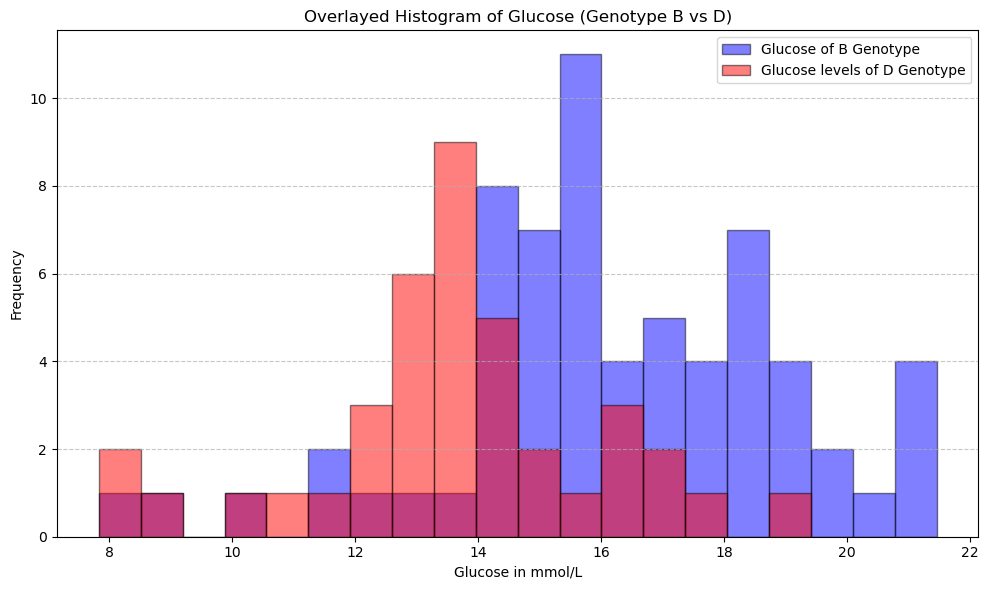

In [130]:
#visualize it with a histogram
sig_geno = geno2['gnf13.099.677']
glucose_B = one_pheno[sig_geno == 0]
glucose_D = one_pheno[sig_geno == 2]

#plot histogram
min_value = min(glucose_B.min(), glucose_D.min())
max_value = max(glucose_B.max(), glucose_D.max())
bins = np.linspace(min_value, max_value, 21) 
plt.figure(figsize=(10, 6))
plt.hist(glucose_B, bins=bins, color='blue', alpha=0.5, edgecolor='black', label='Glucose of B Genotype')
plt.hist(glucose_D, bins=bins, color='red', alpha=0.5, edgecolor='black', label='Glucose levels of D Genotype')
plt.xlabel('Glucose in mmol/L')
plt.ylabel('Frequency')
plt.title('Overlayed Histogram of Glucose (Genotype B vs D)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Now the differences are well pronounced, with the mean of the B genotype being shifted. However, the distributions are sligtly bimodal, and do not fit the assumed normal distribution very well.

## Create a Manhattan plot for the `Glucose_[mmol/L]` phenotype

We see that there are a good bunch of SNPs that appear strongly associated with glucose levels in mice. **Draw a Manhattan plot to see where they cluster on the genome, and do a bit of research to confirm whether what you found is confirmed by the literature on the topic.**

You should obviously re-use your code from the previous notebook to create the plot. You can (and of course should) perform a Benjamini-Hochberg correction on your p-values, but seeing the magnitude of the p-values, the best ones will clearly pass, and since we aren't planning to publish our findings, we won't complain if you just plot them as-is.

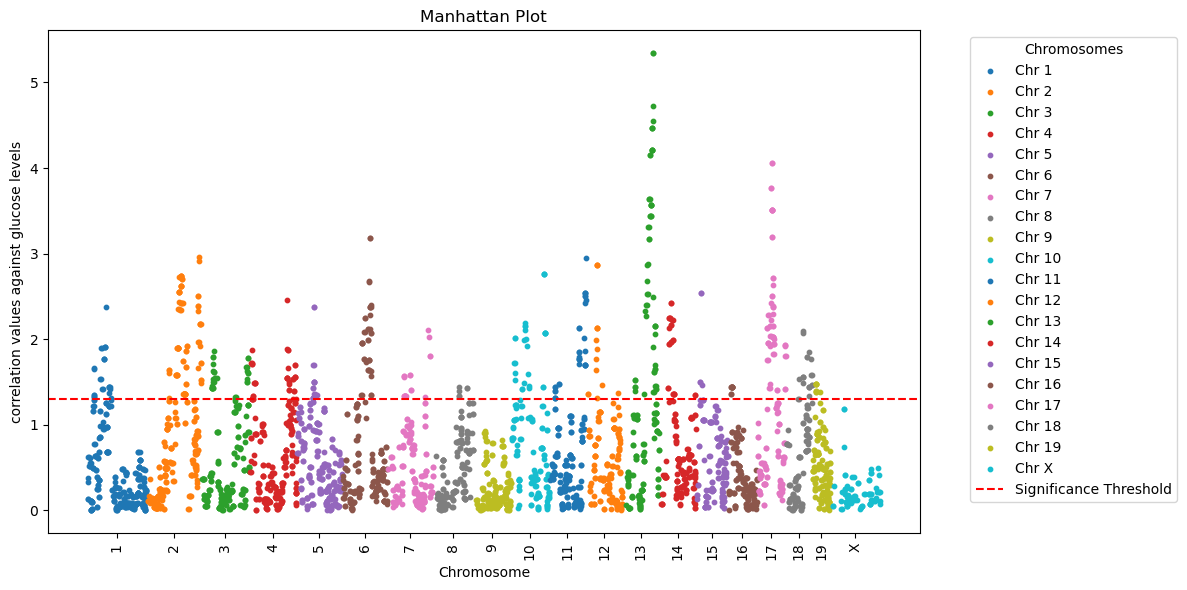

In [131]:
# YOUR CODE HERE
#add necessary data for plotting
geno_meta['cor_p'] = one_pheno_vs_all_geno
geno_meta['cor_log_p'] = -np.log10(geno_meta['cor_p'])
geno_meta['Chr'] = geno_meta['Chr'].astype(str)
chromosome_order = [str(i) for i in range(1, 23)] + ['X', 'Y']
geno_meta['Chr'] = pd.Categorical(geno_meta['Chr'], categories=chromosome_order, ordered=True)

#find offsets for each chromosome and their midpoints for x-axis labeling
chromosome_offsets = geno_meta.groupby('Chr')['Mb'].max().cumsum().shift(fill_value=0)
chromosome_midpoints = chromosome_offsets + geno_meta.groupby('Chr')['Mb'].max() / 2
geno_meta['cumulative_mb'] = geno_meta['Mb'] + geno_meta['Chr'].map(chromosome_offsets)

#plot
plt.figure(figsize=(12, 6))
for chrom, group in geno_meta.groupby('Chr'):
    plt.scatter(group['cumulative_mb'], group['cor_log_p'], s=10, label=f'Chr {chrom}')
plt.axhline(-np.log10(0.05), color='red', linestyle='--', label='Significance Threshold')
plt.xlabel('Chromosome')
plt.xticks(chromosome_midpoints, chromosome_midpoints.index, rotation=90)
plt.ylabel('correlation values against glucose levels')
plt.title('Manhattan Plot')
plt.legend(title='Chromosomes', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

<span style="color:CornflowerBlue">
One can clearly see, that a lot of highly signficiant SNPs lie on chromosome 13, furthermore a lot on 17 and 6. Generally, a lot of the chromosomes have some significant SNPs, probably because there was no multiple testing correction.

# Perform a correlation test between all loci and all phenotypes of a sheet

The inevitable next step: running the Pearson correlation test between all pairs of loci and phenotypes.

If you can run the test between a single phenotype and all columns of `geno2`, you can also run it for every phenotype in the Biochemistry sheet: you just have to iterate over `phenotypes['Biochemistry']`'s columns using the DataFrame's `.iteritems()` method.

All you have to do is collect the resulting p-value Series in a list, concatenate them with `pd.concat` along the horizontal (`1`) axis, and name the columns. You can either name the columns after concatenation, but you can also think ahead and take care of it inside the iteration, right after each p-value Series has just been created. (If `pd.concat` receives a list of named Series, it will know how to name the columns of the concatenated DataFrame).

Name the resulting DataFrame `all_pheno_vs_all_geno`.

In [132]:
# YOUR CODE HERE
all_pheno_vs_all_geno = pd.concat([geno2.apply(lambda g: pearson_between(g, pheno)) for _,pheno in biochem.items()], axis=1)
all_pheno_vs_all_geno.columns = biochem.columns
all_pheno_vs_all_geno

experiment,Glucose_[mmol/L],Cholesterol_[mmol/L],HDL_Norm[Z],LDL_[mmol/L],Triglycerides_[mmol/L],FFA_Norm[Z],LacticAcid_[mmol/L],BloodProtein_[g/L],ASAT_[U/L],ASAT_Norm[Z],LDH_Norm[Z],ALPL_[U/L],Amylase_[U/L],CreatineKinase_[U/L],Creatinine_Norm[Z],Iron_[umol/L]
Locus,,,,,,,,,,,,,,,,
rs6269442,0.748817,0.853085,0.098859,0.873765,0.318344,0.942187,0.012752,0.202258,0.615805,0.393711,0.301918,0.668540,0.370485,0.940243,0.375333,0.012715
rs6365999,0.748817,0.853085,0.098859,0.873765,0.318344,0.942187,0.012752,0.202258,0.615805,0.393711,0.301918,0.668540,0.370485,0.940243,0.375333,0.012715
rs6376963,0.462723,0.251541,0.009490,0.484090,0.741116,0.627840,0.085050,0.072672,0.995115,0.845749,0.791897,0.892510,0.351989,0.818727,0.445999,0.080563
rs3677817,0.417329,0.356267,0.016060,0.554779,0.881356,0.472480,0.120950,0.175424,0.992702,0.825603,0.832591,0.667153,0.161589,0.955060,0.584326,0.028889
rs8236463,0.236964,0.289210,0.020524,0.268463,0.748572,0.312253,0.111566,0.522767,0.989523,0.883261,0.892290,0.098099,0.047812,0.617784,0.163004,0.592612
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CEL-X_154259201,0.609644,0.986843,0.784710,0.579995,0.513750,0.788771,0.207264,0.336455,0.808877,0.999854,0.546350,0.084733,0.102153,0.226959,0.086112,0.711959
rs3657281,0.609644,0.986843,0.784710,0.579995,0.513750,0.788771,0.207264,0.336455,0.808877,0.999854,0.546350,0.084733,0.102153,0.226959,0.086112,0.711959
rs13484106,0.609644,0.986843,0.784710,0.579995,0.513750,0.788771,0.207264,0.336455,0.808877,0.999854,0.546350,0.084733,0.102153,0.226959,0.086112,0.711959


In [133]:
assert 'all_pheno_vs_all_geno' in locals()

# Create a Mann-Whitney U test function similar to `pearson_between`

The Mann-Whitney U test compares a strictly binary categorical variable with a continuous variable. Or in other words: it compares two groups of contiuous values.

Create a `mwu_between(one_geno, one_pheno)` function which performs the Mann-Whitney U test instead of Pearson's correlation. But watch out! The expected input of `stats.mannwhitneyu` is different from that of `stats.pearsonr`: instead of passing a genotype Series and a phenotype Series, you will have to pass two phenotype Series, one containing the phenotype values of B mice (`one_geno == 0`), and the other containing the phenotype values of D mice (`one_geno == 2`).

While having to slice `one_pheno` may seem like extra work, it has an upside: you don't have to bother with the parallel masking of `NaN` values, because `.dropna()` on both Series independently will do just fine.

Try out your `mwu_between` function on the same locus and phenotype that you had used when testing `pearson_between`.

In [134]:
# YOUR CODE HERE
def mwu_between(one_geno, one_pheno):
    group_B = one_pheno[one_geno == 0].dropna()
    group_D = one_pheno[one_geno == 2].dropna()
    stat, p_value = stats.mannwhitneyu(group_B, group_D, alternative='two-sided')
    return p_value
mwu_p = mwu_between(one_geno, one_pheno)
mwu_p

np.float64(0.01738016466332297)

In [135]:
assert math.isclose(mwu_between(geno2['rs3677240'], phenotypes['Biochemistry']['Glucose_[mmol/L]']), 0.0173, abs_tol=1e-4)

# Calculate Mann-Whitney p-values for all loci-phenotype combinations for the Biochemistry sheet

This should be a copy-paste job. It will give you another big matrix with a lot of p-values in them. Let's call it `all_pheno_vs_all_geno_mwu`.

In [136]:
# YOUR CODE HERE
all_pheno_vs_all_geno_mwu = pd.concat([geno2.apply(lambda g: mwu_between(g, pheno)) for _,pheno in biochem.items()], axis=1)
all_pheno_vs_all_geno_mwu.columns = biochem.columns
all_pheno_vs_all_geno_mwu

geno_meta['mwu_p'] = all_pheno_vs_all_geno_mwu['Glucose_[mmol/L]']
geno_meta['mwu_log_p'] = -np.log10(geno_meta['mwu_p'])

In [137]:
assert 'all_pheno_vs_all_geno_mwu' in locals()

To make use of this data, create a `-log10` scatter-plot comparing all of its values with the Pearson's p-values in `all_pheno_vs_all_geno`. **What is the difference between the p-values of both tests?**

<div class="alert alert-block alert-info"><b>Hint 1: </b> You can turn a numpy matrix into a 1-dimensional array with the <code>.flatten()</code> method. You can access a DataFrame's underlying numpy matrix with <code>.values</code>.</div>

<div class="alert alert-block alert-info"><b>Hint 2: </b> To "zoom in" on the interesting p-values, you can change your plot type to log-log (or equivalently, plot the log10 of the p-values).</div>

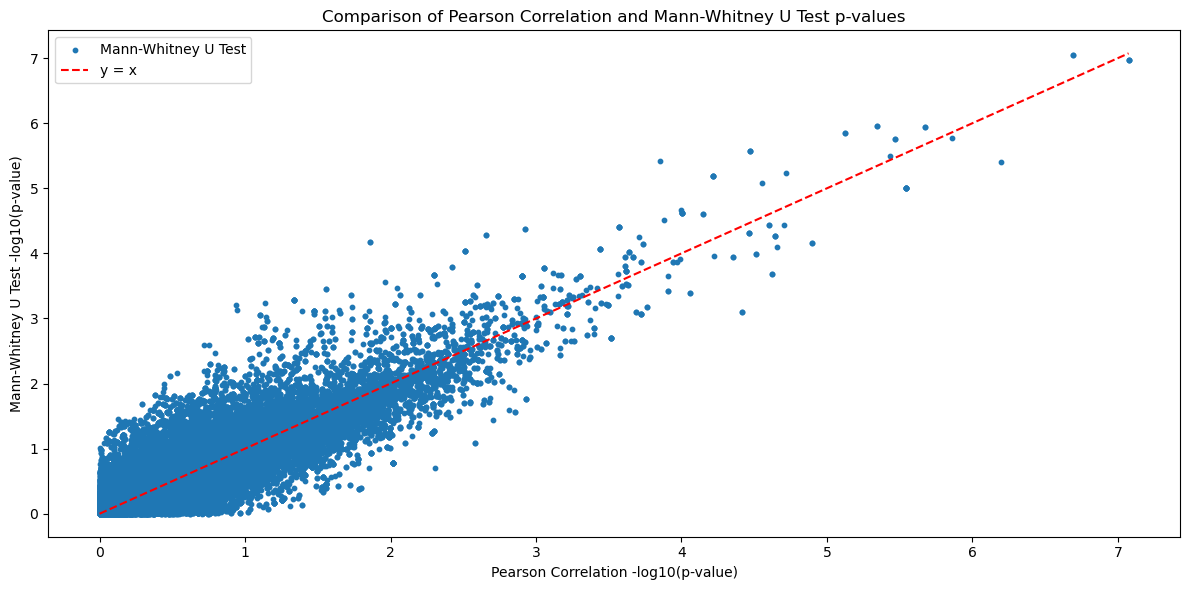

In [205]:
# YOUR CODE HERE
x = -np.log10(all_pheno_vs_all_geno.to_numpy().flatten())
y = -np.log10(all_pheno_vs_all_geno_mwu.to_numpy().flatten())
min_val = min(x.min(), y.min())
max_val = max(x.max(), y.max())

plt.figure(figsize=(12, 6))
plt.scatter(-np.log10(all_pheno_vs_all_geno.to_numpy().flatten()), -np.log10(all_pheno_vs_all_geno_mwu.to_numpy().flatten()), s=10, label='Mann-Whitney U Test')
plt.plot([min_val, max_val], [min_val, max_val], linestyle='--', label='y = x', color='red')
plt.xlabel('Pearson Correlation -log10(p-value)')
plt.ylabel('Mann-Whitney U Test -log10(p-value)')
plt.title('Comparison of Pearson Correlation and Mann-Whitney U Test p-values')
plt.legend()
plt.tight_layout()
plt.show()

It seems like there is a linear relationship between the p-values from both test, altough it looks like the p-values of the correlation rise slightly quicker for high p-values (so low in this plot).

# Multiple testing correction

This is a tricky one. Having calculated p-values for every locus-phenotype pair, we now have a big matrix with tens of thousands of p-values. That's a lot of tests, and therefore they deserve a big, strict correction.

As you will find, the function `multipletests` can only deal with a 1-dimensional array of p-values. This means we will have to:
1. access the DataFrame's underlying numpy matrix with `.values`
2. flatten it into a 1d array
3. run `multipletests(..., method='fdr_bh')` on it
4. reshape it back to the original dimensions
5. turn it back to a DataFrame with the proper indices and columns.
6. Store it as `all_pheno_vs_all_geno_pearson_bh`

These steps will take four lines of code.

In [198]:
# YOUR CODE HERE
all_pheno_vs_all_geno_pearson_bh = stats.false_discovery_control(all_pheno_vs_all_geno, method='bh', axis=0)
all_pheno_vs_all_geno_pearson_bh  = pd.DataFrame(all_pheno_vs_all_geno_pearson_bh, columns=all_pheno_vs_all_geno.columns, index=all_pheno_vs_all_geno.index)
all_pheno_vs_all_geno_pearson_bh

experiment,Glucose_[mmol/L],Cholesterol_[mmol/L],HDL_Norm[Z],LDL_[mmol/L],Triglycerides_[mmol/L],FFA_Norm[Z],LacticAcid_[mmol/L],BloodProtein_[g/L],ASAT_[U/L],ASAT_Norm[Z],LDH_Norm[Z],ALPL_[U/L],Amylase_[U/L],CreatineKinase_[U/L],Creatinine_Norm[Z],Iron_[umol/L]
Locus,,,,,,,,,,,,,,,,
rs6269442,0.930958,0.991072,0.671205,0.999122,0.696957,0.988969,0.277710,0.583045,0.948732,0.921263,0.972397,0.892461,0.801004,0.983603,0.715197,0.178802
rs6365999,0.930958,0.991072,0.671205,0.999122,0.696957,0.988969,0.277710,0.583045,0.948732,0.921263,0.972397,0.892461,0.801004,0.983603,0.715197,0.178802
rs6376963,0.822499,0.938957,0.485650,0.999122,0.931281,0.931953,0.454317,0.404458,0.996422,0.948264,0.989820,0.961543,0.798806,0.965698,0.768448,0.297099
rs3677817,0.795532,0.938957,0.493587,0.999122,0.966908,0.887169,0.535976,0.548345,0.995576,0.937622,0.989820,0.891487,0.667053,0.985292,0.826815,0.215031
rs8236463,0.630205,0.938957,0.504416,0.999122,0.933511,0.861153,0.511647,0.822571,0.994219,0.963322,0.989820,0.439723,0.521919,0.904824,0.536450,0.748822
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CEL-X_154259201,0.890993,0.994140,0.974965,0.999122,0.824592,0.962489,0.663125,0.702036,0.958679,0.999854,0.989820,0.423774,0.616494,0.736931,0.401511,0.836398
rs3657281,0.890993,0.994140,0.974965,0.999122,0.824592,0.962489,0.663125,0.702036,0.958679,0.999854,0.989820,0.423774,0.616494,0.736931,0.401511,0.836398
rs13484106,0.890993,0.994140,0.974965,0.999122,0.824592,0.962489,0.663125,0.702036,0.958679,0.999854,0.989820,0.423774,0.616494,0.736931,0.401511,0.836398


In [199]:
assert 'all_pheno_vs_all_geno_pearson_bh' in locals()

## Are there any locus-phenotype associations that survive multiple testing correction?

In [200]:
# YOUR CODE HERE
threshold = 0.05 
significant = all_pheno_vs_all_geno_pearson_bh[all_pheno_vs_all_geno_pearson_bh < threshold].dropna(how="all")
significant_pairs = significant.stack().reset_index()
significant_pairs.columns = ["Locus", "Phenotype", "p_value"]
print(significant)

experiment       Glucose_[mmol/L]  Cholesterol_[mmol/L]  HDL_Norm[Z]  \
Locus                                                                  
rs13477364                    NaN                   NaN          NaN   
CEL-3_119667160               NaN                   NaN          NaN   
rs13477369                    NaN                   NaN          NaN   
rs6259281                     NaN                   NaN          NaN   
gnf03.125.202                 NaN                   NaN          NaN   
...                           ...                   ...          ...   
rs3709891                0.040364                   NaN          NaN   
rs13483015               0.040364                   NaN          NaN   
rs3690039                0.040364                   NaN          NaN   
rs13483737                    NaN                   NaN          NaN   
gnfX.033.214                  NaN                   NaN          NaN   

experiment       LDL_[mmol/L]  Triglycerides_[mmol/L]  FFA_Norm

Overall we have 96 significant associations between the phenotypes and some loci. The phenotypes are Glucose, LacticAcid (just one), ALPL, Amylase and Creatinine.

## And the question again: could we have overcorrected the data? Why?

Probably yes, since neither the Loci nor the biochemical phenotypes are perfectly independent, for the SNPs because of linkage disequilibrium and for phenotypes because a lot of the biochemical values are also depending on another, or are highly correlated. So theoretically we do less tests, and hence account for too many.

# What confounding factors may have influenced our analysis? How could they be dealt with?

There are a lot of possible confounding factors, ranging from bath effects (one for each genotype), sex efects and having two diets for each genotype could have affected the variance of the diet. Because of that, a lot of the effects could be masked by unwanted technical variance, and looking at a PCA could give indictaions of that.

# Optional: Violin plot for a phenotype sheet

This is a hard one for those that have extra time on their hands.

Pick a phenotype sheet, and create a split violin for every phenotype, stratified by the genotypes on the locus that has the strongest association with the phenotype. A lot of techniques come together in this task, but I guarantee it will fill you with a sense of accomplishment if you pull it off. You have all the ingredients, but it's not trivial to put them together.

In [184]:
print(type(biochem.index))
print(biochem.index[:5])

print(geno2.columns[:5])

<class 'pandas.MultiIndex'>
MultiIndex([(  'BXD1',  'CD'),
            (  'BXD1', 'HFD'),
            ('BXD100',  'CD'),
            ('BXD100', 'HFD'),
            ('BXD101',  'CD')],
           names=['strain', 'diet'])
Index(['rs6269442', 'rs6365999', 'rs6376963', 'rs3677817', 'rs8236463'], dtype='str', name='Locus')


In [194]:
# YOUR CODE HERE 
min_genos = all_pheno_vs_all_geno_pearson_bh.idxmin()
min_genos
records = []
for phenotype, locus in min_genos.items():
    for sample in biochem.index:
        records.append({
            "Phenotype": phenotype,
            "Value": biochem.loc[sample, phenotype],
            "Genotype": geno2.loc[sample,locus],
            "Locus": locus
        })
plot_df = pd.DataFrame(records)
#exlude all 1 genotypes and ignore them 
plot_df = plot_df[plot_df['Genotype'] != 1]

In [ ]:
# unique_phenotypes = plot_df['Phenotype'].unique()

# for phenotype in unique_phenotypes:
#     plt.figure(figsize=(15, 6))
#     df = plot_df[plot_df['Phenotype'] == phenotype]
#     sns.violinplot(
#         data=df, 
#         x='Phenotype',
#         y='Value',  
#         hue='Genotype',
#         split=True,
#         inner='quart',
#         palette='pastel'
#     )
#     plt.title(f'Violin Plot of Genotype Frequencies for {phenotype} for locus {df["Locus"].iloc[0]}')
#     plt.xlabel('Biochemical Property')
#     plt.ylabel('Measurement')
#     plt.tight_layout()
#     plt.show()

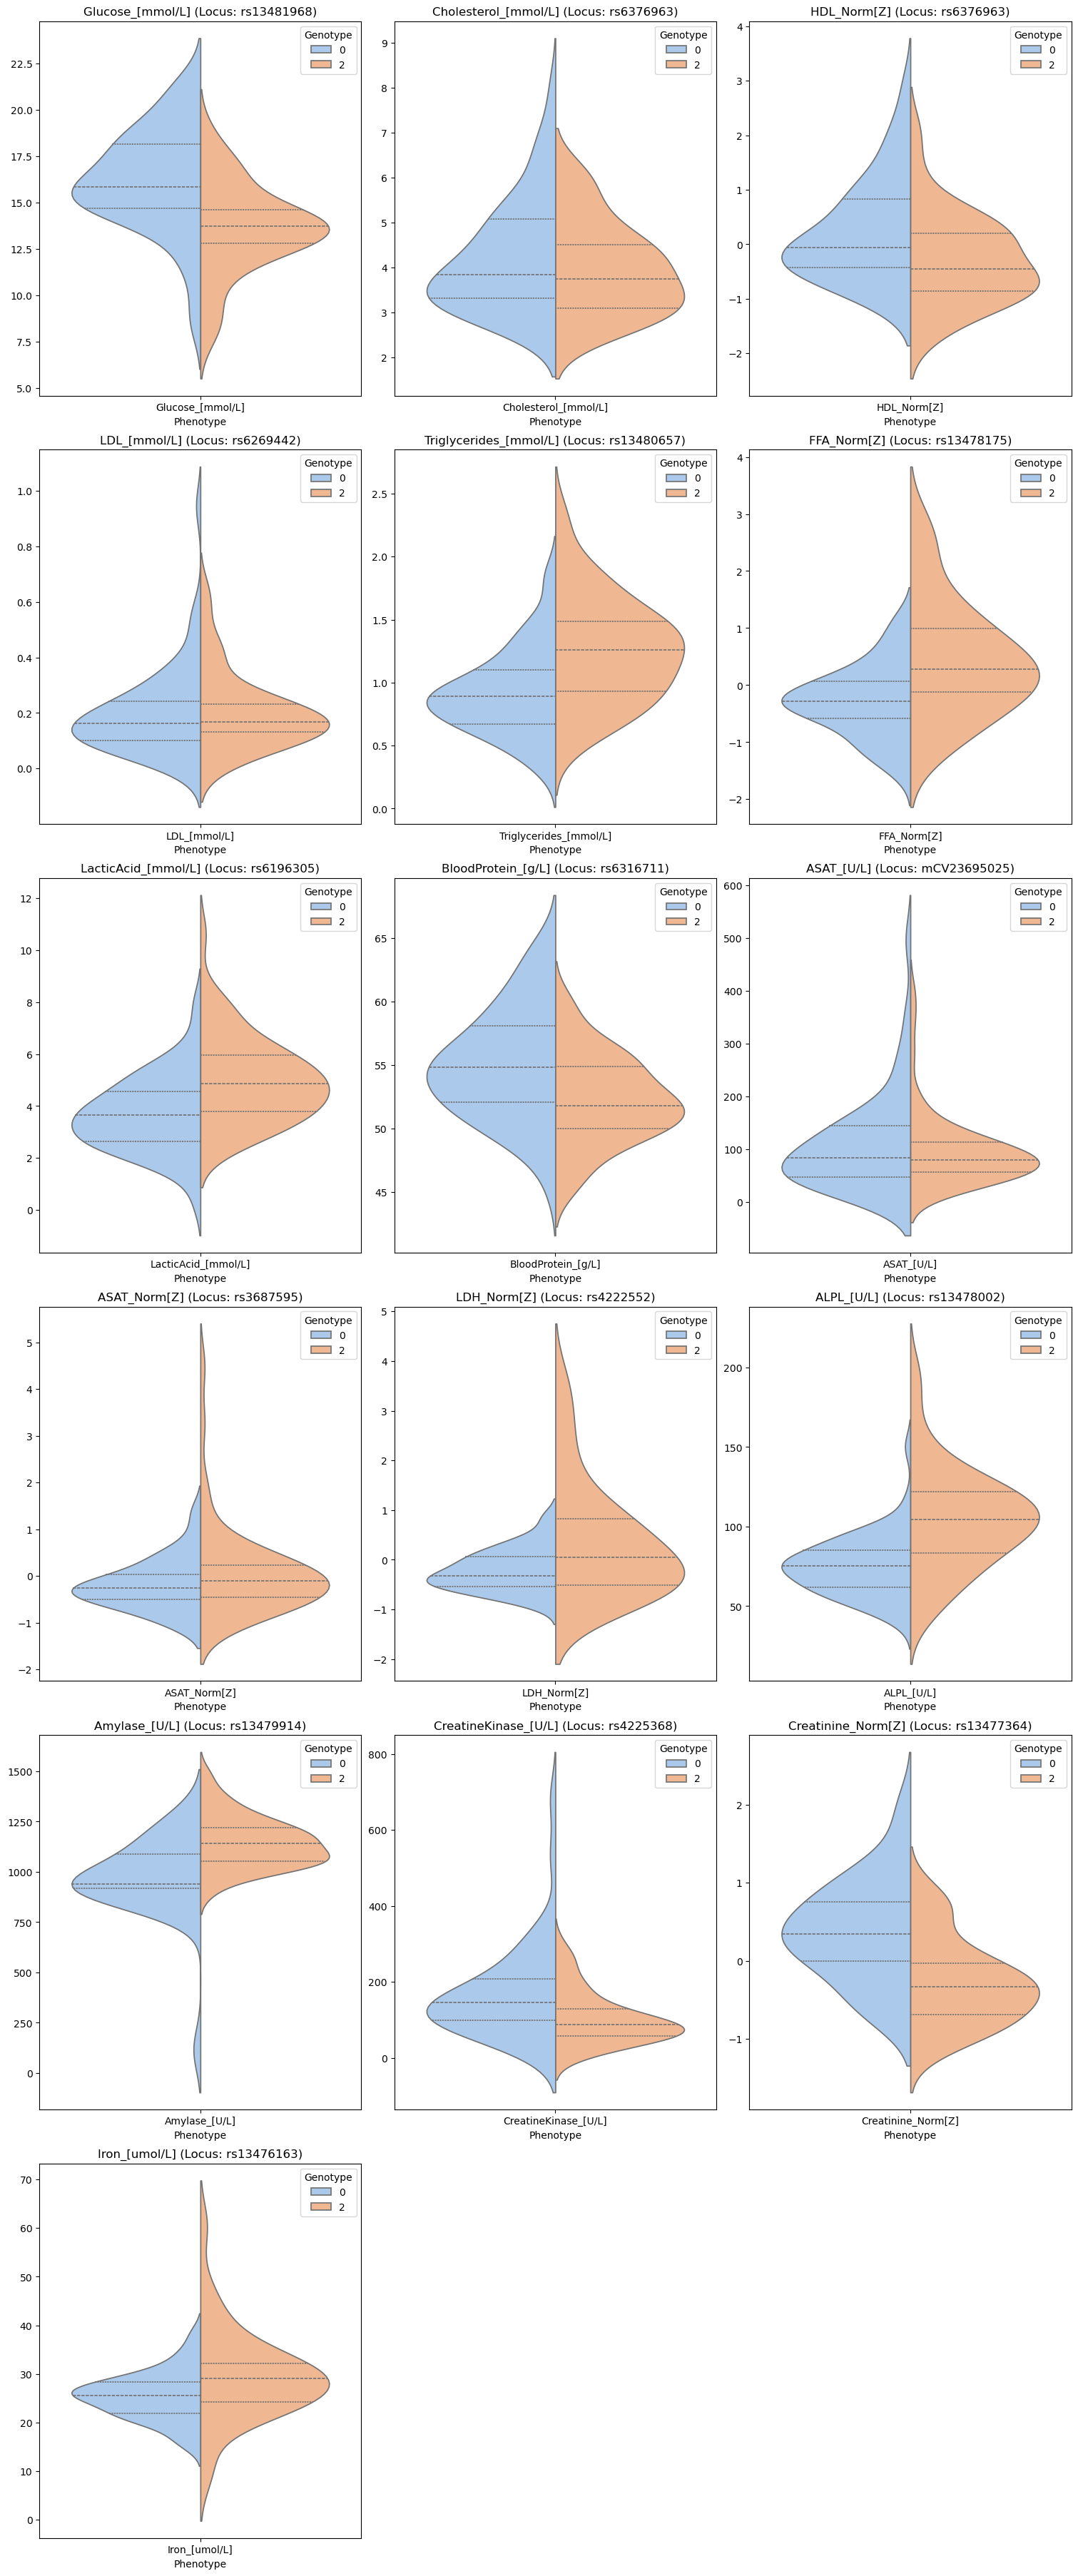

In [204]:
unique_phenotypes = plot_df['Phenotype'].unique()
plots_per_row = 3
num_rows = (len(unique_phenotypes) + plots_per_row - 1) // plots_per_row  # Calculate the number of rows needed
fig, axes = plt.subplots(num_rows, plots_per_row, figsize=(15, 6 * num_rows), constrained_layout=True)
axes = axes.flatten()

for i, phenotype in enumerate(unique_phenotypes):
    ax = axes[i]
    df = plot_df[plot_df['Phenotype'] == phenotype]
    sns.violinplot(
        data=df,
        x='Phenotype',
        y='Value',
        hue='Genotype',
        split=True,
        inner='quart',
        palette='pastel',
        ax=ax
    )
    ax.set_title(f'{phenotype} (Locus: {df["Locus"].iloc[0]})')
    ax.set_ylabel('')
for j in range(len(unique_phenotypes), len(axes)):
    fig.delaxes(axes[j])
plt.show()